# 01 — EDA: Model Rekomendasi Latihan

**Dataset Combined:**
- `gym_members_exercise_tracking.csv` (973 baris, real gym data)
- `gym_members_exercise_tracking_synthetic_data.csv` (1,800 baris, synthetic — schema identik)
- **Combined: 2,773 baris**

**Optional:** `final_dataset_BFP.csv` (5,000 baris) untuk weak label mapping

**Riset acuan:**
- EightGym Indonesia 2024 — XGBoost 95% accuracy untuk gym member classification
- Nature Sci Reports 2025 — feature engineering (BMR, TDEE) improves AUC 3-4 pp

**Tujuan:**
- Combine 2 dataset & verify schema identik
- Distribusi target (Workout_Type, Experience_Level)
- Class imbalance check (untuk SMOTEENN strategy)
- Drift check antara real vs synthetic data
- Outlier detection

**Output:** `output/eda/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='darkgrid')
os.makedirs('output/eda', exist_ok=True)

# ── Path datasets ──
PATH_REAL      = '../../dataset/Model_rekomendasi_Pelatihan/gym_member_exercise_dataset/gym_members_exercise_tracking.csv'
PATH_SYNTHETIC = '../../dataset/Model_Adaptif_Perencanaan_Ulang/Fitness Tracker Dataset/gym_members_exercise_tracking_synthetic_data.csv'
PATH_BFP       = '../../dataset/Model_rekomendasi_Pelatihan/fitness exercises using BFP & BMI/final_dataset_BFP.csv'

df_real      = pd.read_csv(PATH_REAL)
df_synthetic = pd.read_csv(PATH_SYNTHETIC)

print(f'Real dataset:      {df_real.shape}')
print(f'Synthetic dataset: {df_synthetic.shape}')
print(f'\nReal columns:      {list(df_real.columns)}')
print(f'Synthetic columns: {list(df_synthetic.columns)}')

Real dataset:      (973, 15)
Synthetic dataset: (1800, 15)

Real columns:      ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']
Synthetic columns: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']


In [2]:
# ── Verify Schema Match ──
assert list(df_real.columns) == list(df_synthetic.columns), 'Schema MISMATCH! Cannot concat.'
print('✅ Schema match — bisa di-concat')

# Add source flag
df_real['data_source'] = 'real'
df_synthetic['data_source'] = 'synthetic'

df = pd.concat([df_real, df_synthetic], ignore_index=True)
print(f'\n✅ Combined dataset: {df.shape}')
df.head(3)

✅ Schema match — bisa di-concat

✅ Combined dataset: (2773, 16)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,data_source
0,56.0,Male,88.3,1.71,180,157.0,60.0,1.69,1313.0,Yoga,12.6,3.5,4.0,3.0,30.20,real
1,46.0,Female,74.9,1.53,179,151.0,66.0,1.30,883.0,HIIT,33.9,2.1,4.0,2.0,32.00,real
2,32.0,Female,68.1,1.66,167,122.0,54.0,1.11,677.0,Cardio,33.4,2.3,4.0,2.0,24.71,real


In [3]:
# ── Basic Info & Missing Values ──
print('='*60)
print('INFO')
print('='*60)
df.info()

print('\n' + '='*60)
print('MISSING VALUES')
print('='*60)
print(df.isnull().sum())

print('\n' + '='*60)
print('DESCRIBE')
print('='*60)
df.describe().round(2)

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2773 entries, 0 to 2772
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            2763 non-null   float64
 1   Gender                         2702 non-null   object 
 2   Weight (kg)                    2751 non-null   float64
 3   Height (m)                     2747 non-null   float64
 4   Max_BPM                        2752 non-null   object 
 5   Avg_BPM                        2743 non-null   float64
 6   Resting_BPM                    2754 non-null   float64
 7   Session_Duration (hours)       2750 non-null   float64
 8   Calories_Burned                2750 non-null   float64
 9   Workout_Type                   2712 non-null   object 
 10  Fat_Percentage                 2757 non-null   float64
 11  Water_Intake (liters)          2749 non-null   float64
 12  Workout_Frequency (days/week)  2715 non-nul

,Age,Weight (kg),Height (m),Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,2763.00,2751.00,2747.00,2743.00,2754.00,2750.00,2750.00,2757.00,2749.00,2715.00,2716.00,2743.00
mean,35.96,69.82,1.73,145.38,63.34,1.34,988.31,24.03,2.68,3.33,1.82,21.72
std,12.43,20.56,0.13,14.96,7.77,0.37,315.55,6.05,0.67,0.94,0.74,7.02
min,18.00,40.00,1.50,120.00,50.00,0.50,303.00,10.00,1.50,2.00,1.00,12.32
25%,25.00,54.90,1.64,132.00,57.00,1.10,763.00,20.80,2.10,3.00,1.00,16.24
50%,35.00,67.00,1.73,145.00,64.00,1.32,969.00,24.90,2.70,3.00,2.00,20.83
75%,47.00,82.40,1.82,158.00,71.00,1.57,1189.75,28.20,3.30,4.00,2.00,25.73
max,59.00,129.90,2.00,169.00,74.00,2.00,1783.00,35.00,3.70,5.00,3.00,49.84


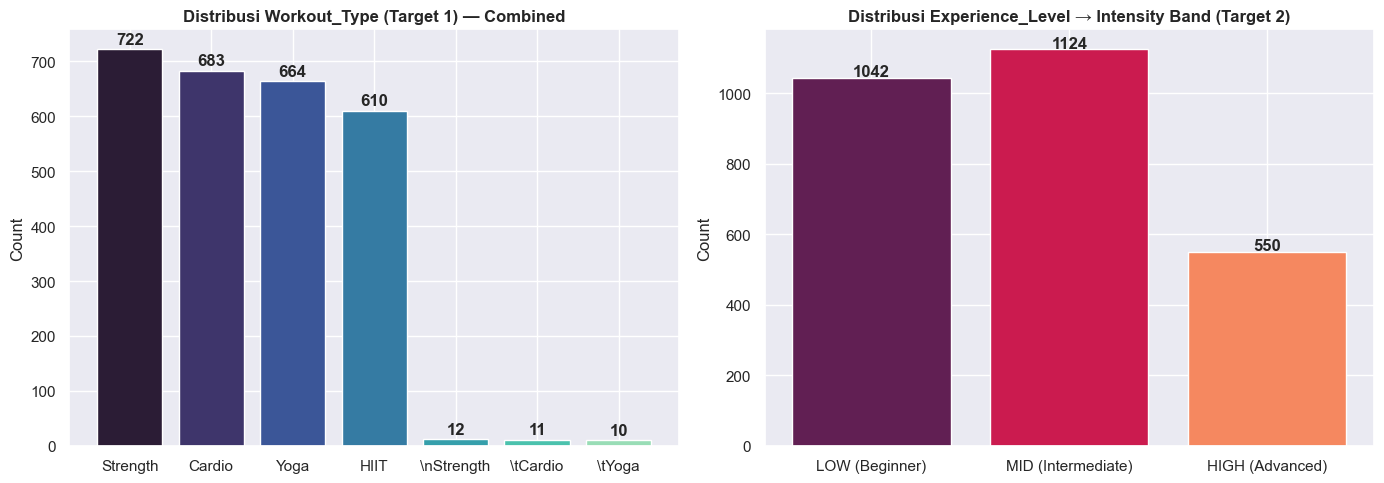


Class imbalance ratio (Workout_Type): 72.20:1
⚠️ Imbalance detected → akan pakai SMOTEENN di preprocessing


In [4]:
# ── Target Variable Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Workout_Type
workout_counts = df['Workout_Type'].value_counts()
axes[0].bar(workout_counts.index, workout_counts.values,
            color=sns.color_palette('mako', len(workout_counts)))
axes[0].set_title('Distribusi Workout_Type (Target 1) — Combined', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(workout_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Experience_Level → Intensity Band
exp_counts = df['Experience_Level'].value_counts().sort_index()
exp_labels = {1: 'LOW (Beginner)', 2: 'MID (Intermediate)', 3: 'HIGH (Advanced)'}
axes[1].bar(
    [exp_labels[k] for k in exp_counts.index],
    exp_counts.values,
    color=sns.color_palette('rocket', 3)
)
axes[1].set_title('Distribusi Experience_Level → Intensity Band (Target 2)', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(exp_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('output/eda/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Class imbalance check
ratio_workout = workout_counts.max() / workout_counts.min()
print(f'\nClass imbalance ratio (Workout_Type): {ratio_workout:.2f}:1')
if ratio_workout > 2:
    print('⚠️ Imbalance detected → akan pakai SMOTEENN di preprocessing')
else:
    print('✅ Class balance acceptable')

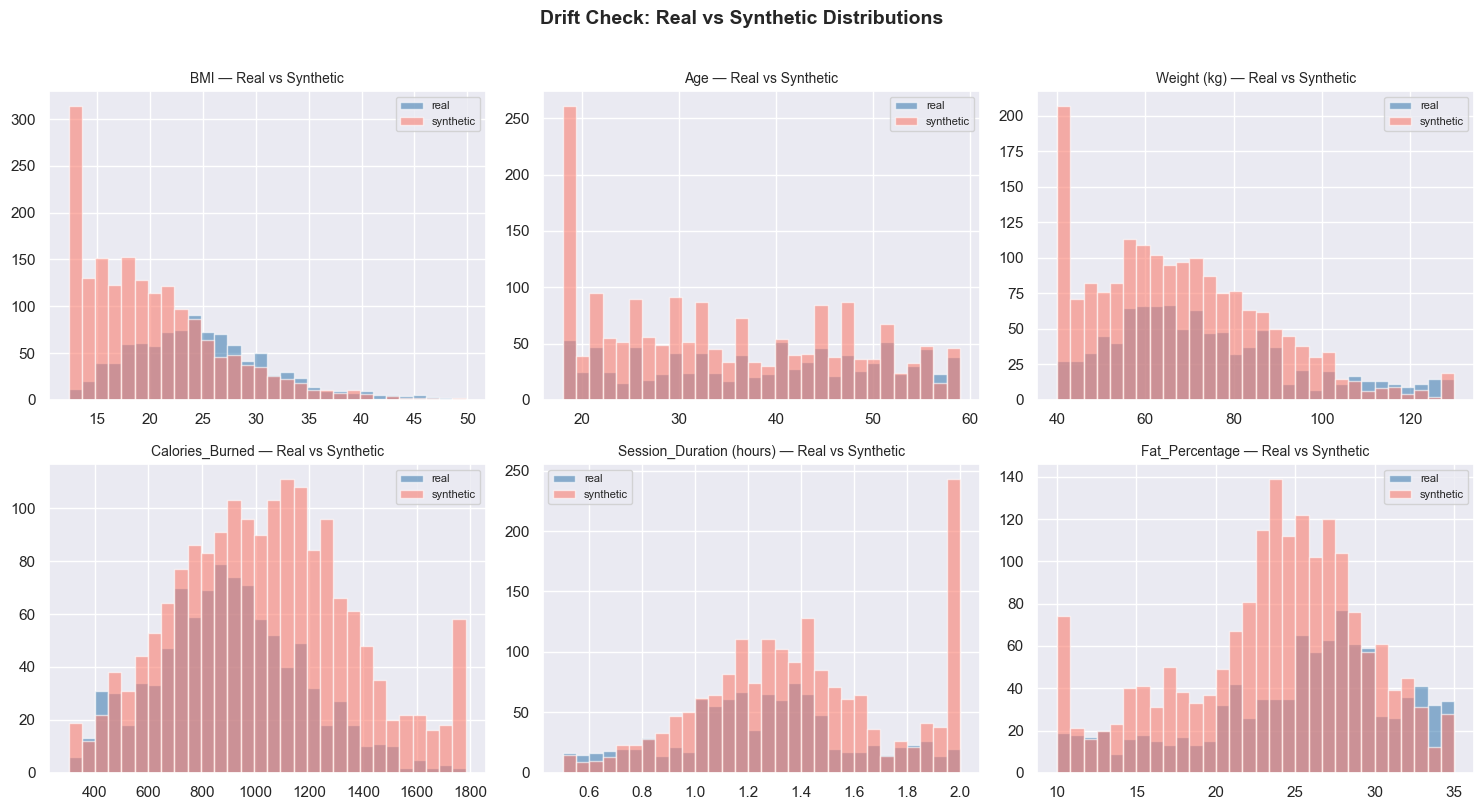


KS-test untuk drift (p-value > 0.05 = distribusi mirip):
  BMI                            p-value=0.0000 ⚠️ drift detected
  Age                            p-value=0.0000 ⚠️ drift detected
  Weight (kg)                    p-value=0.0000 ⚠️ drift detected
  Calories_Burned                p-value=0.0000 ⚠️ drift detected
  Session_Duration (hours)       p-value=0.0000 ⚠️ drift detected
  Fat_Percentage                 p-value=0.0000 ⚠️ drift detected


In [6]:
# ── Real vs Synthetic Drift Check (penting!) ──
# Membandingkan distribusi real & synthetic untuk pastikan synthetic representative
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

drift_cols = ['BMI', 'Age', 'Weight (kg)', 'Calories_Burned',
              'Session_Duration (hours)', 'Fat_Percentage']

for ax, col in zip(axes, drift_cols):
    if col in df.columns:
        for src, color in [('real', 'steelblue'), ('synthetic', 'salmon')]:
            subset = df[df['data_source'] == src][col].dropna()
            ax.hist(subset, bins=30, alpha=0.6, label=src,
                    color=color, edgecolor='white')
        ax.set_title(f'{col} — Real vs Synthetic', fontsize=10)
        ax.legend(fontsize=8)

plt.suptitle('Drift Check: Real vs Synthetic Distributions',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/eda/real_vs_synthetic_drift.png', dpi=150, bbox_inches='tight')
plt.show()

# Kolmogorov-Smirnov test untuk drift detection (statistical)
from scipy.stats import ks_2samp
print('\nKS-test untuk drift (p-value > 0.05 = distribusi mirip):')
for col in drift_cols:
    if col in df.columns:
        a = df[df['data_source']=='real'][col].dropna()
        b = df[df['data_source']=='synthetic'][col].dropna()
        stat, pval = ks_2samp(a, b)
        flag = '✅ similar' if pval > 0.05 else '⚠️ drift detected'
        print(f'  {col:30s} p-value={pval:.4f} {flag}')

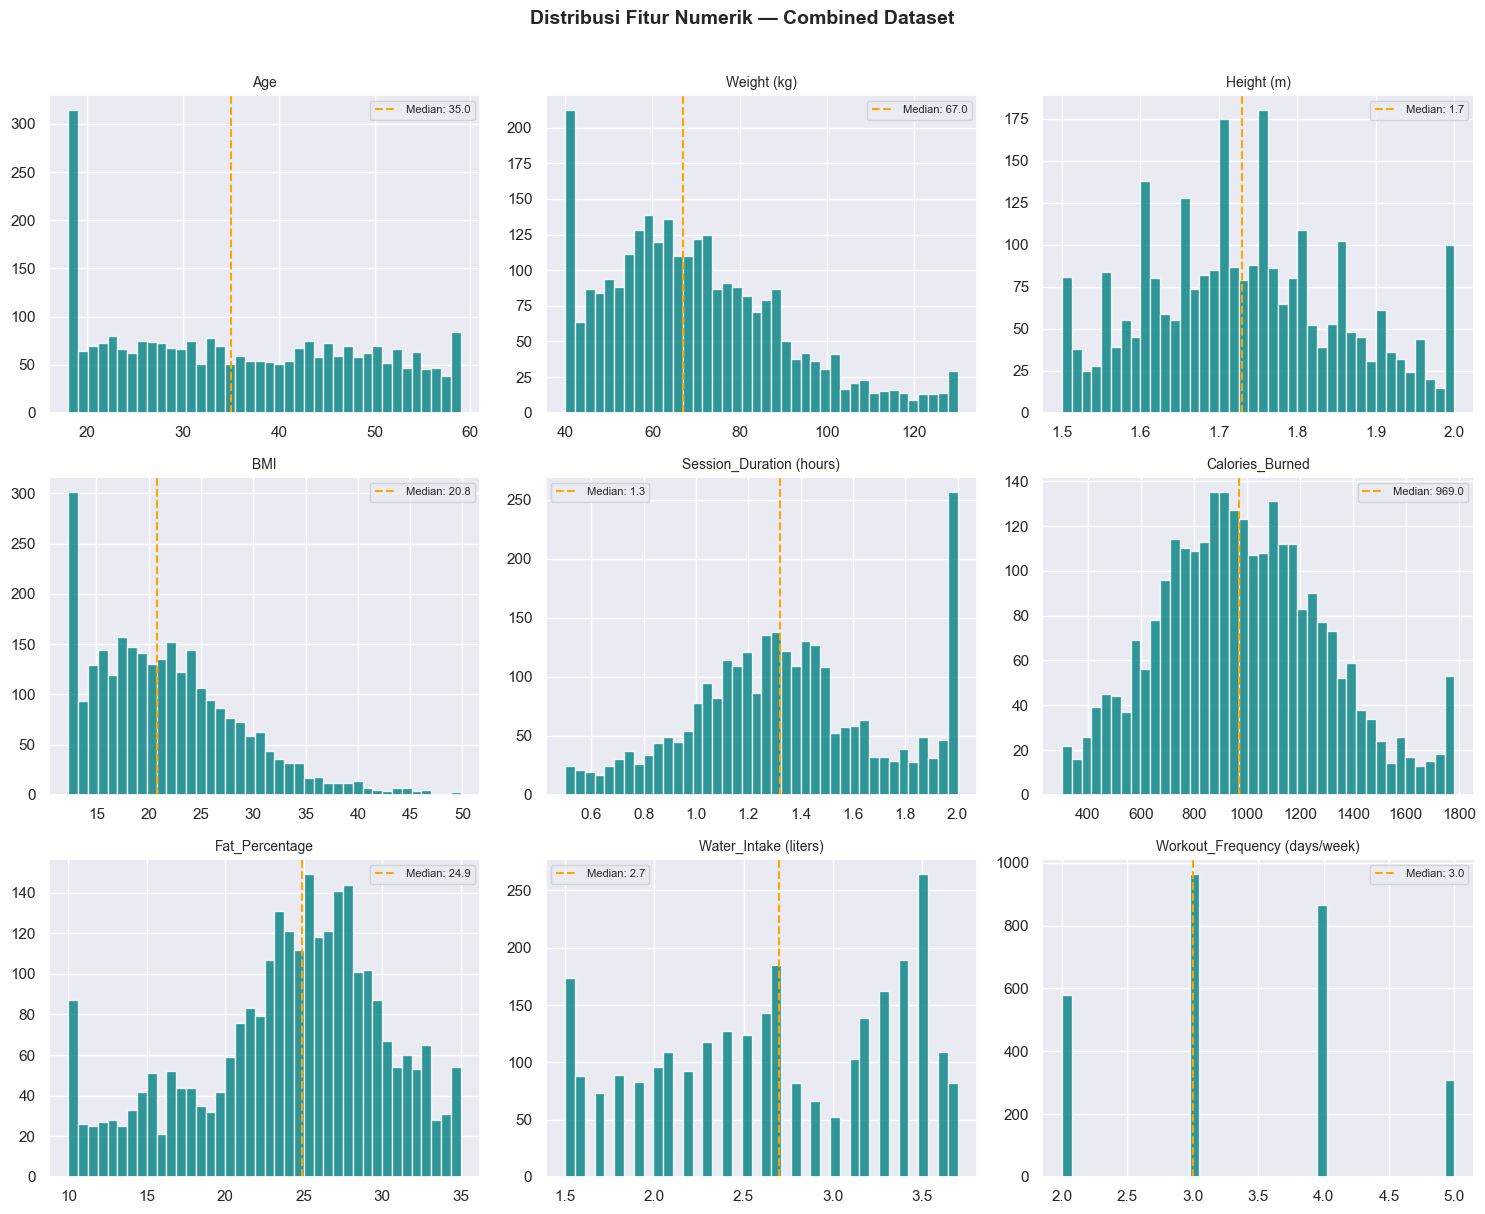

In [7]:
# ── Distribusi Fitur Numerik (Combined) ──
num_cols = ['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Session_Duration (hours)',
            'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)',
            'Workout_Frequency (days/week)']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=40, color='teal',
                     edgecolor='white', alpha=0.8)
        axes[i].set_title(col, fontsize=10)
        axes[i].axvline(df[col].median(), color='orange', linestyle='--',
                        label=f'Median: {df[col].median():.1f}')
        axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Fitur Numerik — Combined Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/eda/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

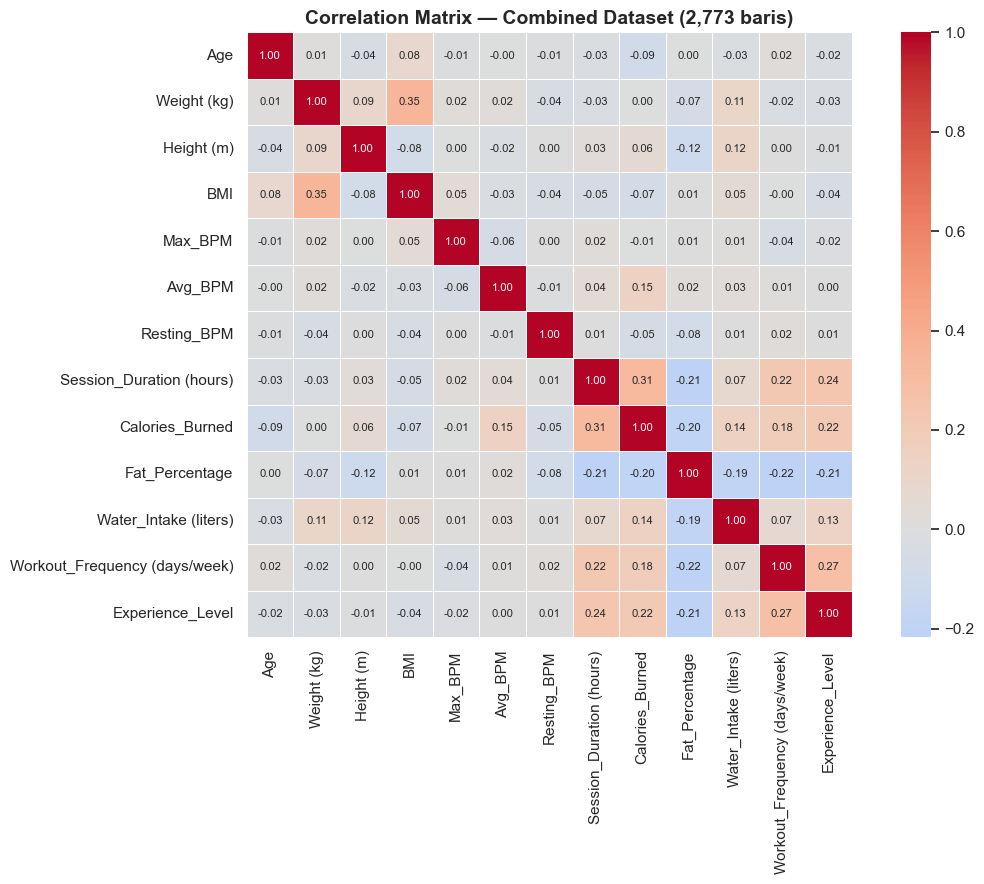

In [8]:
# ── Correlation Heatmap ──
corr_cols = ['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Max_BPM', 'Avg_BPM',
             'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
             'Fat_Percentage', 'Water_Intake (liters)',
             'Workout_Frequency (days/week)', 'Experience_Level']
corr_cols = [c for c in corr_cols if c in df.columns]

plt.figure(figsize=(12, 9))

numeric_df = df[corr_cols].copy()
numeric_df = numeric_df.replace(r'\s+', '', regex=True)
numeric_df = numeric_df.apply(pd.to_numeric, errors='coerce')
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix — Combined Dataset (2,773 baris)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/eda/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── Outlier Detection ──
print('=== Outlier Detection (IQR method) ===')
outlier_cols = ['BMI', 'Calories_Burned', 'Fat_Percentage']
for col in outlier_cols:
    if col in df.columns:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        print(f'  {col:30s}: {len(outliers):4d} outliers ({len(outliers)/len(df)*100:.1f}%)')
        print(f'    Bounds: [{lower:.2f}, {upper:.2f}]')

print('\n→ RobustScaler akan dipakai (handle outliers dengan median+IQR)')

=== Outlier Detection (IQR method) ===
  BMI                           :   52 outliers (1.9%)
    Bounds: [2.00, 39.97]
  Calories_Burned               :    0 outliers (0.0%)
    Bounds: [122.88, 1829.88]
  Fat_Percentage                :    0 outliers (0.0%)
    Bounds: [9.70, 39.30]

→ RobustScaler akan dipakai (handle outliers dengan median+IQR)


In [10]:
# ── Optional: BFP Dataset Inspection ──
try:
    df_bfp = pd.read_csv(PATH_BFP)
    print(f'BFP Dataset: {df_bfp.shape}')
    print(f'Kolom: {list(df_bfp.columns)}')
    print('\nExercise Recommendation Plan distribution:')
    print(df_bfp['Exercise Recommendation Plan'].value_counts().sort_index())
    print('\n→ BFP dataset bisa jadi WEAK LABEL untuk validation rules,')
    print('  TIDAK di-concat ke training karena schema beda.')
except Exception as e:
    print(f'BFP dataset tidak tersedia: {e}')

BFP Dataset: (5000, 9)
Kolom: ['Weight', 'Height', 'BMI', 'Body Fat Percentage', 'BFPcase', 'Gender', 'Age', 'BMIcase', 'Exercise Recommendation Plan']

Exercise Recommendation Plan distribution:
Exercise Recommendation Plan
1     211
2     135
3     263
4    1458
5    1230
6     843
7     860
Name: count, dtype: int64

→ BFP dataset bisa jadi WEAK LABEL untuk validation rules,
  TIDAK di-concat ke training karena schema beda.


In [11]:
# ── Save Summary ──
import json

summary = {
    'dataset_sources': {
        'real': len(df_real),
        'synthetic': len(df_synthetic),
        'combined': len(df),
    },
    'missing_values': int(df.isnull().sum().sum()),
    'workout_type_distribution': df['Workout_Type'].value_counts().to_dict(),
    'intensity_distribution': df['Experience_Level'].value_counts().to_dict(),
    'class_imbalance_ratio': float(ratio_workout),
    'needs_smoteenn': bool(ratio_workout > 2),
    'recommended_scaler': 'RobustScaler',
    'bmi_range': f"{df['BMI'].min():.2f} – {df['BMI'].max():.2f}",
    'age_range': f"{int(df['Age'].min())} – {int(df['Age'].max())}",
    'datasets_will_combine': True,
    'augmentation_target_rows': len(df) * 7,
}

with open('output/eda/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('✅ EDA selesai.')
print(f'\nCombined dataset: {len(df)} baris')
print(f'Target augmentation: {len(df) * 7} baris (7-day expansion)')
print(f'Class imbalance: {ratio_workout:.2f}:1 → {"SMOTEENN required" if ratio_workout > 2 else "balanced OK"}')

✅ EDA selesai.

Combined dataset: 2773 baris
Target augmentation: 19411 baris (7-day expansion)
Class imbalance: 72.20:1 → SMOTEENN required
